Room Temperature (K):  301.100 K
Resistivity (Ohm·m): 0.001415 Ω·m
Hall Coefficient RH (m^3/C): 0.076200 m^3/C
Equal B-field: 185.70768817734174 Gauss


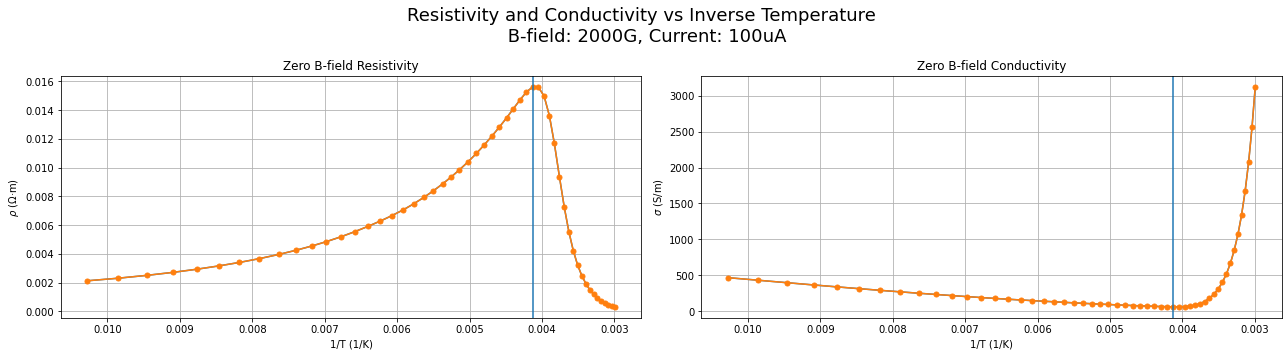

Extrinsic and Intrinsic region transition at 0.00413.


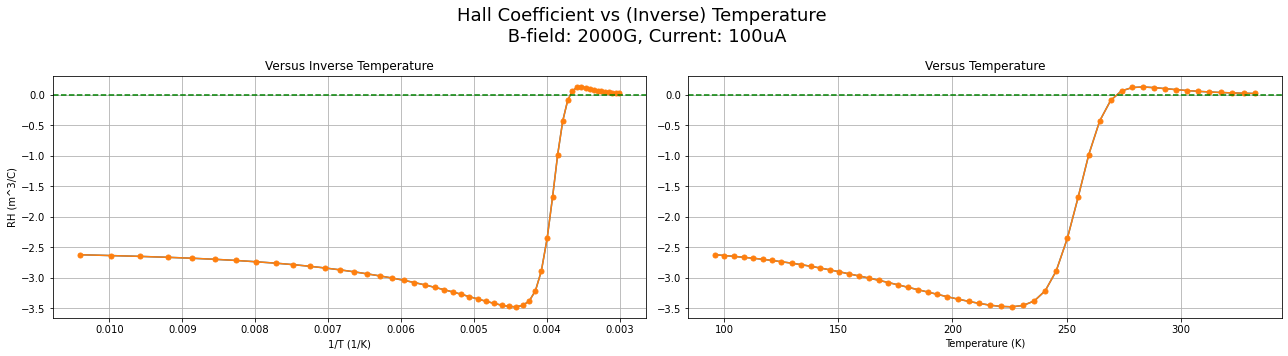

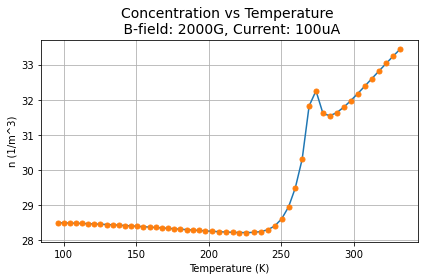

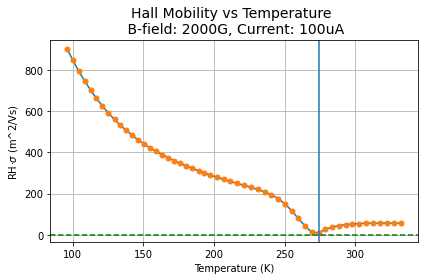

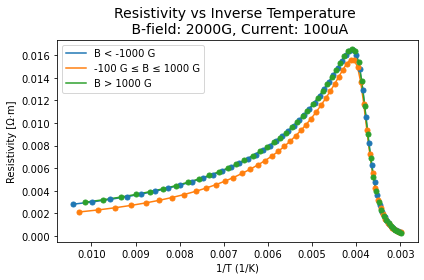

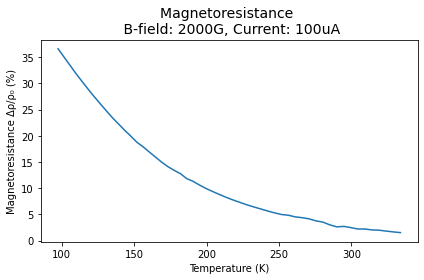

MR at 300 K: 2.47 %


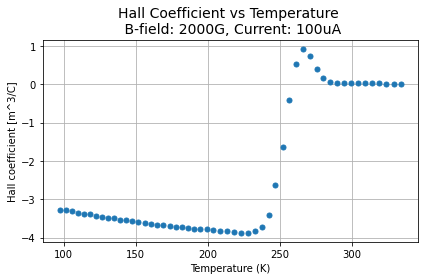

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Semiconductor Dimensions
width = 10.0/100
length = 10.0/100
thickness = 1.25/1000
cross_area = width * thickness
I = 100e-6
q = 1.602e-19


 ## 2000 G B-field ##



# Load the 2000G raw data file
df_2000G = pd.read_csv("2000G100uA.txt", sep="\t", engine="python")

# Convert required columns to numeric
cols_to_convert = ["Temperature (K)", "Voltage AC", "Voltage BD", "B-Field (Gauss)"]
for col in cols_to_convert:
    df_2000G[col] = pd.to_numeric(df_2000G[col], errors="coerce")

# Drop rows with missing values in any of those columns
df_2000G = df_2000G.dropna(subset=cols_to_convert)

# Split the data into three B-field ranges
df2000_B_neg = df_2000G[df_2000G["B-Field (Gauss)"] < -1000].copy()
df2000_B_zero = df_2000G[(df_2000G["B-Field (Gauss)"] >= -1000) & (df_2000G["B-Field (Gauss)"] <= 1000)].copy()
df2000_B_pos = df_2000G[df_2000G["B-Field (Gauss)"] > 1000].copy()

for df in [df2000_B_neg, df2000_B_zero, df2000_B_pos]:
    df["1/T (1/K)"] = 1 / pd.to_numeric(df["Temperature (K)"])
    df["B (T)"] = df["B-Field (Gauss)"] / 1e4
    df["V_rho"] = 0.5 * (df["Voltage DC"] - df["Voltage -DC"])
    df["V_hall"] = 0.5 * ((0.5 * (df["Voltage BD"] - df["Voltage -BD"])) + (0.5 * (df["Voltage AC"] - df["Voltage -AC"])))
    

df2_B_neg = df2000_B_neg[["Temperature (K)", "1/T (1/K)", "V_rho", "V_hall", "B (T)"]].to_numpy()
df2_B_zero = df2000_B_zero[["Temperature (K)", "1/T (1/K)", "V_rho", "V_hall", "B (T)"]].to_numpy()
df2_B_pos = df2000_B_pos[["Temperature (K)", "1/T (1/K)", "V_rho", "V_hall", "B (T)"]].to_numpy()


neg_temp = df2_B_neg[:, 0]
neginv_temp = df2_B_neg[:, 1]
negv_rho = df2_B_neg[:, 2]
negv_hall = df2_B_neg[:, 3]
negb_field = df2_B_neg[:, 4]

pos_temp = df2_B_pos[:, 0]
posinv_temp = df2_B_pos[:, 1]
posv_rho = df2_B_pos[:, 2]
posv_hall = df2_B_pos[:, 3]
posb_field = df2_B_pos[:, 4]

zero_temp = df2_B_zero[:, 0]
zeroinv_temp = df2_B_zero[:, 1]
zerov_rho = df2_B_zero[:, 2]
zerov_hall = df2_B_zero[:, 3]
zerob_field = df2_B_zero[:, 4]



# Compute physical quantities - Negative
neg_resis = np.abs((negv_rho / I) * 0.01 * cross_area / length)
neg_conduc = 1 / neg_resis
neg_RH = (negv_hall * thickness) / (I * negb_field)
#neg_concentration = 1 / (np.abs(neg_RH) * q)
#neg_mobility = np.abs(neg_RH) * neg_conduc
neg_semi_type = np.where(neg_RH > 0, "p-type", "n-type")

# Compute physical quantities - Positive
pos_resis = np.abs((posv_rho*0.01 * cross_area) / (I * length))
pos_conduc = 1 / pos_resis
pos_RH = (posv_hall * thickness) / (I * posb_field)
#pos_concentration = 1 / (np.abs(pos_RH) * q)
#pos_mobility = np.abs(pos_RH) * pos_conduc
pos_semi_type = np.where(pos_RH > 0, "p-type", "n-type")

# Compute physical quantities - Zero
zero_resis = np.abs((zerov_rho*0.01 * cross_area) / (I * length))
zero_conduc = 1 / zero_resis
zero_RH = (zerov_hall * thickness) / (I * zerob_field)
#zero_concentration = 1 / (np.abs(zero_RH) * q)
#zero_mobility = np.abs(zero_RH) * zero_conduc
#zero_semi_type = np.where(zero_RH > 0, "p-type", "n-type") 



#ROOM TEMPERATURE CALCULATION
idx_RT = np.argmin(np.abs(pos_temp - 300))

T_RT = pos_temp[idx_RT]
rho_RT = pos_resis[idx_RT]
RH_RT = pos_RH[idx_RT]

B_eq_RT = (rho_RT / np.abs(RH_RT)) * 1e4

# Output
print(f"Room Temperature (K): {T_RT: .3f} K")
print(f"Resistivity (Ohm·m): {rho_RT:.6f} Ω·m")
print(f"Hall Coefficient RH (m^3/C): {RH_RT:.6f} m^3/C")
print(f"Equal B-field: {B_eq_RT} Gauss")



#RESISTIVITY & CONDUCTIVITY VS INVERSE TEMPERATURE
def plot_two_b_field_resisconduc():
    import matplotlib.pyplot as plt

    fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

    # -1000 G ≤ B ≤ 1000 G
    axs[0].plot(zeroinv_temp, zero_resis)
    axs[0].plot(zeroinv_temp, zero_resis, '-o', ms=5)
    axs[0].set_title("Zero B-field Resistivity")
    axs[0].set_xlabel("1/T (1/K)")
    axs[0].set_ylabel(r"$\rho$ (Ω·m)")
    axs[0].axvline(zeroinv_temp[zero_resis.argmax()])
    axs[0].grid(True)

    # -1000 G ≤ B ≤ 1000 G
    axs[1].plot(zeroinv_temp, zero_conduc)
    axs[1].plot(zeroinv_temp, zero_conduc, '-o', ms=5)
    axs[1].set_title("Zero B-field Conductivity")
    axs[1].set_xlabel("1/T (1/K)")
    axs[1].set_ylabel(r"$\sigma$ (S/m)")
    axs[1].axvline(zeroinv_temp[zero_conduc.argmin()])
    axs[1].grid(True)
    
    # Ensure y-ticks and labels on all plots
    for ax in axs:
        ax.yaxis.set_ticks_position('left')
        ax.yaxis.set_label_position('left')
        ax.tick_params(labelleft=True)
        ax.invert_xaxis()
    

    plt.suptitle('Resistivity and Conductivity vs Inverse Temperature \n B-field: 2000G, Current: 100uA', fontsize=18)

    plt.tight_layout()
    plt.show()
    
    print(f"Extrinsic and Intrinsic region transition at {zeroinv_temp[zero_resis.argmax()]:.3g}.")
    
plot_two_b_field_resisconduc()



# HALL COEFF VS INVERSE TEMPERATURE
def plot_two_b_field_hall():
    import matplotlib.pyplot as plt
    anti_RH = 0.5 * ((pos_RH)+(neg_RH))
    
    fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

    # B < -1000 G
    axs[0].plot(neginv_temp, anti_RH)
    axs[0].plot(neginv_temp, anti_RH, '-o', ms=5)
    axs[0].set_title("Versus Inverse Temperature")
    axs[0].set_xlabel("1/T (1/K)")
    axs[0].set_ylabel("RH (m^3/C)")
    axs[0].invert_xaxis()
    axs[0].axhline(y=0, color='g', linestyle = '--')
    axs[0].grid(True)


    # B > 1000 G
    axs[1].plot(neg_temp, anti_RH)
    axs[1].plot(neg_temp, anti_RH, '-o', ms=5)
    axs[1].set_title("Versus Temperature")
    axs[1].set_xlabel("Temperature (K)")
    axs[1].axhline(y=0, color='g', linestyle = '--')
    axs[1].grid(True)
    
    plt.suptitle('Hall Coefficient vs (Inverse) Temperature \n B-field: 2000G, Current: 100uA', fontsize=18)
    

    #plt.plot(neginv_temp, anti_RH)
    #plt.plot(neginv_temp, anti_RH, 'o', ms=5)
    #plt.gca().invert_xaxis()
    #plt.xlabel("1/T (1/K)")
    #plt.ylabel("Hall coefficient [m^3/C]")
    #plt.axhline(y=0, color='g', linestyle = '--')
    #plt.title('Hall Coefficient vs Inverse Temperature \n B-field: 2000G, Current: 100uA', fontsize=14)
    #plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_two_b_field_hall()



# CONCENTRATION VS TEMPERATURE
def plot_two_b_field_concen():
    import matplotlib.pyplot as plt

    #fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

    # B < -1000 G
    #axs[0].plot(neg_temp, np.log(neg_concentration), '-o')
    #axs[0].set_title("B < -1000 G")
    #axs[0].set_xlabel("Temperature (K)")
    #axs[0].set_ylabel("Carrier Concentration (1/m^3)")
    #axs[0].grid(True)


    # B > 1000 G
    #axs[1].plot(pos_temp, np.log(pos_concentration), '-o')
    #axs[1].set_title("B > 1000 G")
    #axs[1].set_xlabel("Temperature (K)")
    #axs[1].grid(True)
    
    #plt.suptitle('Concentration vs Temperature \n B-field: 2000G, Current: 100uA', fontsize=18)

    anti_RH = 0.5 * ((pos_RH)+(neg_RH))
    anti_n = (1.0 / (q * np.abs(anti_RH)))/1e6
    plt.plot(neg_temp, np.log(anti_n))
    plt.plot(neg_temp, np.log(anti_n), 'o', ms=5)
    plt.xlabel("Temperature (K)")
    plt.ylabel("n (1/m^3)")
    plt.title('Concentration vs Temperature \n B-field: 2000G, Current: 100uA', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
plot_two_b_field_concen()



# MOBILITY VS TEMPERATURE
def plot_two_b_field_mobil():
    import matplotlib.pyplot as plt

    #fig, axs = plt.subplots(1, 2, figsize=(18, 5), sharey=False)

    # B < -1000 G
    #axs[0].plot(neg_temp, neg_mobility, '-o')
    #axs[0].set_title("B < -1000 G")
    #axs[0].set_xlabel("Temperature (K)")
    #axs[0].set_ylabel("Mobility (m^2/Vs)")
    #axs[0].grid(True)


    # B > 1000 G
    #axs[1].plot(pos_temp, pos_mobility, '-o')
    #axs[1].set_title("B > 1000 G")
    #axs[1].set_xlabel("Temperature (K)")
    #axs[1].grid(True)
    
    #plt.suptitle('Hall Mobility vs Temperature \n B-field: 2000G, Current: 100uA', fontsize=18)

    pos_mobility = np.abs(pos_RH) * pos_conduc
    neg_mobility = np.abs(neg_RH) * neg_conduc
    anti_mu = 0.5 * ((pos_mobility)+(neg_mobility))
    plt.plot(neg_temp, anti_mu)
    plt.plot(neg_temp, anti_mu, 'o', ms=5)
    plt.xlabel("Temperature (K)")
    plt.ylabel(r"RH$\dot \sigma$ (m^2/Vs)")
    plt.axhline(y=0, color='g', linestyle = '--')
    plt.axvline(neg_temp[anti_mu.argmin()])
    plt.title('Hall Mobility vs Temperature \n B-field: 2000G, Current: 100uA', fontsize=14)
    plt.grid(True)
    plt.tight_layout()
    plt.show()
    
    
plot_two_b_field_mobil()


mask_ex = (neg_temp > 90) & (neg_temp < 242)

anti_RH = 0.5 * ((pos_RH)+(neg_RH))
anti_n = (1.0 / (q * np.abs(anti_RH)))/1e6
pos_mobility = np.abs(pos_RH) * pos_conduc
neg_mobility = np.abs(neg_RH) * neg_conduc
anti_mu = 0.5 * ((pos_mobility)+(neg_mobility))

n_mask = anti_n[mask_ex]
mu_mask = anti_mu[mask_ex]

n_mean_mask = np.mean(n_mask)
mu_mean_mask = np.mean(mu_mask)

# Magnetoresistance
def plot_resis():
    import matplotlib.pyplot as plt
    
    plt.plot(neginv_temp, neg_resis, color = 'tab:blue', label = "B < -1000 G")
    plt.plot(zeroinv_temp, zero_resis, color = 'tab:orange', label = "-100 G ≤ B ≤ 1000 G")
    plt.plot(posinv_temp, pos_resis, color = 'tab:green', label = "B > 1000 G")
    plt.plot(neginv_temp, neg_resis, 'o', color = 'tab:blue', ms=5)
    plt.plot(zeroinv_temp, zero_resis, 'o', color = 'tab:orange', ms=5)
    plt.plot(posinv_temp, pos_resis, 'o', color = 'tab:green', ms=5)
    plt.gca().invert_xaxis()
    plt.xlabel("1/T (1/K)")
    plt.ylabel("Resistivity [Ω·m]")
    plt.legend()
    plt.title('Resistivity vs Inverse Temperature \n B-field: 2000G, Current: 100uA', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
plot_resis()

def plot_MR():
    import matplotlib.pyplot as plt
    
    neg_MR = (neg_resis - zero_resis) / zero_resis * 100.0
    pos_MR = (pos_resis - zero_resis) / zero_resis * 100.0
    MR = 0.5 * (neg_MR + pos_MR)
    temp = 0.5 * (neg_temp + pos_temp)

    plt.plot(temp, MR)
    plt.xlabel("Temperature (K)")
    plt.ylabel("Magnetoresistance Δρ/ρ₀ (%)")
    plt.title('Magnetoresistance \n B-field: 2000G, Current: 100uA', fontsize=14)
    
    plt.tight_layout()
    plt.show()
    
    idx0 = np.argmin(np.abs(zero_temp - 300))
    idx_pos = np.argmin(np.abs(pos_temp - 300))
    idx_neg = np.argmin(np.abs(neg_temp - 300))

    MR_avg_300 = 0.5 * (pos_MR[idx_pos] + neg_MR[idx_neg])
    print(f"MR at 300 K: {MR_avg_300:.3g} %")
    
plot_MR()

def plot_zero_hall():
    import matplotlib.pyplot as plt

    plt.plot(zero_temp, zero_RH, 'o', ms=5)
    plt.xlabel("Temperature (K)")
    plt.ylabel("Hall coefficient [m^3/C]")
    plt.title('Hall Coefficient vs Temperature \n B-field: 2000G, Current: 100uA', fontsize=14) 
    plt.grid(True)

    plt.tight_layout()
    plt.show()
    
plot_zero_hall()

In [2]:
# after many months of working on this, I am once again finished! I do have to say, I wrote a whole helper function to create 72 graphs for me that I never used in this lab report. So good job me and thank you as always to ChatGPT.